<a href="https://colab.research.google.com/github/ranjetmahato416/-Lung-CT-Image-Classification-Using-Public-Medical-Imaging-Data-/blob/main/Desktop/Colab_Notebook/Notebook/Notebook_12_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 12 — ResNet50 Baseline and Fine-Tuning

This notebook trains and evaluates a ResNet50 model for binary lung nodule malignancy classification.

The experiment follows the same patient-level data splits, preprocessing pipeline, class-weighting strategy, augmentation policy, evaluation metrics and threshold-selection procedure used for EfficientNetB0 and DenseNet121.

Two ResNet50 configurations are evaluated:

1. Frozen ImageNet-pretrained ResNet50 backbone.
2. Fine-tuned ResNet50 with the final 30 backbone layers unfrozen while BatchNormalization layers remain frozen.

The better configuration is selected using validation PR-AUC. Only the selected configuration is evaluated on the untouched test set.

##2. Imports

In [ ]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path

import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.applications import ResNet50


print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2


##3. Reproducibility

In [ ]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic operations enabled.")
except Exception as error:
    print(
        "Deterministic operations could not be enabled:",
        error
    )

Random seed: 42
TensorFlow deterministic operations enabled.


##4. Mount Google Drive

In [ ]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##5. Define project paths

In [ ]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Dissertation"
)

DATASET_SPLIT_DIR = (
    PROJECT_ROOT
    / "Dataset"
    / "Processed"
)

MODEL_ROOT = (
    PROJECT_ROOT
    / "Models"
    / "ResNet50"
    / "Corrected_Run_01"
)

BASELINE_DIR = (
    MODEL_ROOT
    / "Baseline"
)

FINE_TUNE_DIR = (
    MODEL_ROOT
    / "FineTune_Last30"
)

RESULTS_DIR = (
    MODEL_ROOT
    / "Results"
)

BASELINE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINE_TUNE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Model root:", MODEL_ROOT)

Project root: /content/drive/MyDrive/Dissertation
Model root: /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01


###Define checkpoint paths

In [ ]:
# ============================================================
# Model Output Paths
# ============================================================

RESNET_BASELINE_BEST = (
    BASELINE_DIR
    / "best_model.keras"
)

RESNET_BASELINE_FINAL = (
    BASELINE_DIR
    / "final_model.keras"
)

RESNET_BASELINE_HISTORY = (
    BASELINE_DIR
    / "training_history.csv"
)

RESNET_FINE_TUNE_BEST = (
    FINE_TUNE_DIR
    / "best_model.keras"
)

RESNET_FINE_TUNE_FINAL = (
    FINE_TUNE_DIR
    / "final_model.keras"
)

RESNET_FINE_TUNE_HISTORY = (
    FINE_TUNE_DIR
    / "training_history.csv"
)

print("Baseline checkpoint:", RESNET_BASELINE_BEST)
print("Fine-tuned checkpoint:", RESNET_FINE_TUNE_BEST)

##6. Load the same patient-levevel splits

In [ ]:
# ============================================================
# Load Patient-Level Data Splits
# ============================================================

TRAIN_CSV = (
    DATASET_SPLIT_DIR
    / "train.csv"
)

VALIDATION_CSV = (
    DATASET_SPLIT_DIR
    / "validation.csv"
)

TEST_CSV = (
    DATASET_SPLIT_DIR
    / "test.csv"
)

train_df = pd.read_csv(TRAIN_CSV)
validation_df = pd.read_csv(VALIDATION_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Test samples:", len(test_df))

In [ ]:
print("Training columns:")
print(train_df.columns.tolist())

display(train_df.head())

###Verify class distribution

In [ ]:
def show_class_distribution(df, split_name):

    counts = (
        df["CancerLabel"]
        .value_counts()
        .sort_index()
    )

    percentages = (
        df["CancerLabel"]
        .value_counts(
            normalize=True
        )
        .sort_index()
        * 100
    )

    summary = pd.DataFrame(
        {
            "Count": counts,
            "Percentage": percentages
        }
    )

    print(f"\n{split_name} distribution:")
    display(summary)


show_class_distribution(
    train_df,
    "Training"
)

show_class_distribution(
    validation_df,
    "Validation"
)

show_class_distribution(
    test_df,
    "Test"
)

##7. Global configuration

In [ ]:
# ============================================================
# Global Configuration
# ============================================================

IMAGE_SIZE = (
    128,
    128
)

BATCH_SIZE = 16

AUTOTUNE = tf.data.AUTOTUNE

BASELINE_EPOCHS = 30

FINE_TUNE_EPOCHS = 20

BASELINE_LEARNING_RATE = 1e-4

FINE_TUNE_LEARNING_RATE = 1e-5

LAST_N_LAYERS = 30

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Baseline epochs:", BASELINE_EPOCHS)
print("Fine-tuning epochs:", FINE_TUNE_EPOCHS)

##8. Compute class weights

In [ ]:
# ============================================================
# Calculate Class Weights
# ============================================================

training_labels = (
    train_df["CancerLabel"]
    .values
    .astype(np.int32)
)

class_counts = np.bincount(
    training_labels
)

total_samples = len(training_labels)

class_weights = {
    class_index:
        total_samples
        /
        (
            len(class_counts)
            * class_count
        )

    for class_index, class_count
    in enumerate(class_counts)
}

print("Class counts:", class_counts)
print("Class weights:", class_weights)

##9. Image Loading Function

In [ ]:
# ============================================================
# Image Loading Function
# ============================================================

def load_image(image_path, label):

    image_bytes = tf.io.read_file(
        image_path
    )

    image = tf.image.decode_png(
        image_bytes,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method=tf.image.ResizeMethod.BILINEAR
    )

    image = tf.cast(
        image,
        tf.float32
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label

##10. Data augmentation

In [ ]:
# ============================================================
# Data Augmentation
# ============================================================

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(
                IMAGE_SIZE[0],
                IMAGE_SIZE[1],
                3
            )
        ),

        tf.keras.layers.RandomFlip(
            mode="horizontal"
        ),

        tf.keras.layers.RandomRotation(
            factor=0.05
        ),

        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10
        ),

        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        )
    ],
    name="data_augmentation"
)

##11. Build Tensorflow datasets

In [ ]:
# ============================================================
# Build TensorFlow Dataset
# ============================================================

def build_dataset(df, training=False):

    paths = (
        df["ImagePath"]
        .values
    )

    labels = (
        df["CancerLabel"]
        .values
        .astype(np.int32)
    )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                paths,
                labels
            )
        )
    )

    if training:

        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

###Create datasets:

In [ ]:
train_ds = build_dataset(
    train_df,
    training=True
)

validation_ds = build_dataset(
    validation_df,
    training=False
)

test_ds = build_dataset(
    test_df,
    training=False
)

##12. Validate the data pipeline

In [ ]:
# ============================================================
# Verify TensorFlow Dataset
# ============================================================

for images, labels in train_ds.take(1):

    print(
        "Image batch shape:",
        images.shape
    )

    print(
        "Label batch shape:",
        labels.shape
    )

    print(
        "Image dtype:",
        images.dtype
    )

    print(
        "Label dtype:",
        labels.dtype
    )

    print(
        "Minimum image value:",
        float(
            tf.reduce_min(images)
        )
    )

    print(
        "Maximum image value:",
        float(
            tf.reduce_max(images)
        )
    )

##13. Serializable ResNet50 preprocessing layer

In [ ]:
# ============================================================
# Serializable ResNet50 Preprocessing Layer
# ============================================================

@tf.keras.utils.register_keras_serializable(
    package="LungNoduleClassification"
)
class ResNetPreprocessing(
    tf.keras.layers.Layer
):

    def call(self, inputs):

        return (
            tf.keras.applications.resnet50
            .preprocess_input(inputs)
        )

    def get_config(self):

        return super().get_config()

##14. Build frozen ReseNet50 backbone

In [ ]:
# ============================================================
# Build Frozen ResNet50 Backbone
# ============================================================

resnet_base = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        3
    )
)

resnet_base.trainable = False

print(
    "ResNet50 backbone layers:",
    len(resnet_base.layers)
)

print(
    "Backbone trainable:",
    resnet_base.trainable
)

##15. Build the baseline classification model

In [ ]:
# ============================================================
# Build ResNet50 Baseline Model
# ============================================================

inputs = tf.keras.Input(
    shape=(
        IMAGE_SIZE[0],
        IMAGE_SIZE[1],
        3
    ),
    name="input_image"
)

x = data_augmentation(
    inputs
)

x = ResNetPreprocessing(
    name="resnet50_preprocessing"
)(x)

x = resnet_base(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = tf.keras.layers.Dropout(
    rate=0.30,
    name="dropout"
)(x)

outputs = tf.keras.layers.Dense(
    units=1,
    activation="sigmoid",
    name="binary_output"
)(x)

resnet_baseline_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_LungNoduleClassifier"
)

resnet_baseline_model.summary()

##16. Compile the baseline model

In [ ]:
# ============================================================
# Compile Baseline ResNet50
# ============================================================

resnet_baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=BASELINE_LEARNING_RATE
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

print(
    "ResNet50 baseline compiled with learning rate:",
    BASELINE_LEARNING_RATE
)

##17. Baseline callbacks

In [ ]:
# ============================================================
# Baseline Callback Paths
# ============================================================

BASELINE_LOG_DIR = (
    BASELINE_DIR
    / "logs"
)

BASELINE_BACKUP_DIR = (
    BASELINE_DIR
    / "training_backup"
)

BASELINE_LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

###Callbacks

In [ ]:
# ============================================================
# Baseline Callbacks
# ============================================================

resnet_baseline_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            RESNET_BASELINE_BEST
        ),
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=7,
        min_delta=0.002,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(
            RESNET_BASELINE_HISTORY
        ),
        append=True
    ),

    tf.keras.callbacks.TensorBoard(
        log_dir=str(
            BASELINE_LOG_DIR
        )
    ),

    tf.keras.callbacks.BackupAndRestore(
        backup_dir=str(
            BASELINE_BACKUP_DIR
        ),
        save_freq="epoch",
        delete_checkpoint=False
    )
]

##18. Train the frozen baseline

In [ ]:
# ============================================================
# Train Frozen ResNet50 Baseline
# ============================================================

resnet_baseline_history = (
    resnet_baseline_model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=BASELINE_EPOCHS,
        class_weight=class_weights,
        callbacks=resnet_baseline_callbacks,
        verbose=1
    )
)

Epoch 29/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8078 - auc: 0.8602 - loss: 0.4801 - pr_auc: 0.5418 - precision: 0.3673 - recall: 0.7868
Epoch 29: val_pr_auc did not improve from 0.45742
72/72 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8146 - auc: 0.8728 - loss: 0.4596 - pr_auc: 0.5709 - precision: 0.3759 - recall: 0.7730 - val_accuracy: 0.8354 - val_auc: 0.8008 - val_loss: 0.3977 - val_pr_auc: 0.4566 - val_precision: 0.3659 - val_recall: 0.5357 - learning_rate: 2.0000e-05
Epoch 30/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7951 - auc: 0.8565 - loss: 0.5007 - pr_auc: 0.5482 - precision: 0.3648 - recall: 0.7953
Epoch 30: val_pr_auc did not improve from 0.45742
72/72 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.7850 - auc: 0.8527 - loss: 0.5024 - pr_auc: 0.5440 - precision: 0.3364 - recall: 0.7730 - val_accuracy: 0.8354 - val_auc: 0.7984 - val_loss: 0.3970 - val_pr_auc: 0.4549 - val_precision: 0.3659 - val_recall: 0.5357 - learning_rate: 2.0000e-05
Rest

##19. Save baseline outputs

In [ ]:
# ============================================================
# Save Baseline Final Model
# ============================================================

resnet_baseline_model.save(
    RESNET_BASELINE_FINAL
)

print(
    "Saved baseline final model:",
    RESNET_BASELINE_FINAL
)

print(
    "Saved baseline history:",
    RESNET_BASELINE_HISTORY
)

Saved baseline final model: /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/Baseline/final_model.keras
Saved baseline history: /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/Baseline/training_history.csv


##20. Reload the best baseline checkpoint

In [ ]:
# ============================================================
# Reload Best Baseline Checkpoint
# ============================================================

resnet_baseline_best = (
    tf.keras.models.load_model(
        RESNET_BASELINE_BEST,
        custom_objects={
            "ResNetPreprocessing":
                ResNetPreprocessing,

            "LungNoduleClassification>"
            "ResNetPreprocessing":
                ResNetPreprocessing
        },
        compile=False
    )
)

print(
    "Loaded best ResNet50 baseline:"
)

print(
    RESNET_BASELINE_BEST
)

print(
    "Input shape:",
    resnet_baseline_best.input_shape
)

print(
    "Output shape:",
    resnet_baseline_best.output_shape
)

Loaded best ResNet50 baseline:
/content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/Baseline/best_model.keras
Input shape: (None, 128, 128, 3)
Output shape: (None, 1)


##21. Generate baseline validation predictions

In [ ]:
# ============================================================
# Baseline Validation Predictions
# ============================================================

validation_true = np.concatenate(
    [
        labels.numpy()
        for images, labels
        in validation_ds
    ]
).astype(int)

resnet_baseline_validation_prob = (
    resnet_baseline_best.predict(
        validation_ds,
        verbose=1
    )
    .ravel()
)

print(
    "Validation labels:",
    validation_true.shape
)

print(
    "Baseline predictions:",
    resnet_baseline_validation_prob.shape
)

print(
    "Malignant validation cases:",
    validation_true.sum()
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
Validation labels: (237,)
Baseline predictions: (237,)
Malignant validation cases: 28


##22. Baseline validation ROC-AUC and PR-AUC

In [ ]:
# ============================================================
# Baseline Validation Metrics
# ============================================================

resnet_baseline_val_roc_auc = (
    roc_auc_score(
        validation_true,
        resnet_baseline_validation_prob
    )
)

resnet_baseline_val_pr_auc = (
    average_precision_score(
        validation_true,
        resnet_baseline_validation_prob
    )
)

print(
    "ResNet50 baseline validation ROC-AUC:",
    round(
        resnet_baseline_val_roc_auc,
        6
    )
)

print(
    "ResNet50 baseline validation PR-AUC:",
    round(
        resnet_baseline_val_pr_auc,
        6
    )
)

ResNet50 baseline validation ROC-AUC: 0.797847
ResNet50 baseline validation PR-AUC: 0.467531


##23. Baseline F1 threshold

In [ ]:
# ============================================================
# Baseline Validation F1 Threshold
# ============================================================

baseline_precision_values, \
baseline_recall_values, \
baseline_thresholds = precision_recall_curve(
    validation_true,
    resnet_baseline_validation_prob
)

baseline_f1_values = (
    2
    * baseline_precision_values[:-1]
    * baseline_recall_values[:-1]
    /
    (
        baseline_precision_values[:-1]
        + baseline_recall_values[:-1]
        + 1e-8
    )
)

baseline_best_f1_index = np.argmax(
    baseline_f1_values
)

resnet_baseline_f1_threshold = float(
    baseline_thresholds[
        baseline_best_f1_index
    ]
)

resnet_baseline_best_val_f1 = float(
    baseline_f1_values[
        baseline_best_f1_index
    ]
)

print(
    "Baseline F1 threshold:",
    resnet_baseline_f1_threshold
)

print(
    "Baseline validation F1:",
    resnet_baseline_best_val_f1
)

Baseline F1 threshold: 0.8047968149185181
Baseline validation F1: 0.47826086480151236


###Evaluate

In [ ]:
resnet_baseline_validation_pred = (
    resnet_baseline_validation_prob
    >= resnet_baseline_f1_threshold
).astype(int)

resnet_baseline_cm = confusion_matrix(
    validation_true,
    resnet_baseline_validation_pred
)

print(
    "Baseline validation confusion matrix:"
)

print(
    resnet_baseline_cm
)

print(
    classification_report(
        validation_true,
        resnet_baseline_validation_pred,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

Baseline validation confusion matrix:
[[202   7]
 [ 17  11]]
              precision    recall  f1-score   support

      Benign     0.9224    0.9665    0.9439       209
   Malignant     0.6111    0.3929    0.4783        28

    accuracy                         0.8987       237
   macro avg     0.7667    0.6797    0.7111       237
weighted avg     0.8856    0.8987    0.8889       237



##24. Baseline high-recall threshold

In [ ]:
# ============================================================
# Baseline High-Recall Threshold
# ============================================================

TARGET_RECALL = 0.75

eligible_indices = np.where(
    baseline_recall_values[:-1]
    >= TARGET_RECALL
)[0]

if len(eligible_indices) == 0:

    raise ValueError(
        "No baseline threshold achieved "
        "the target recall."
    )

baseline_high_recall_index = (
    eligible_indices[
        np.argmax(
            baseline_precision_values[:-1][
                eligible_indices
            ]
        )
    ]
)

resnet_baseline_high_recall_threshold = float(
    baseline_thresholds[
        baseline_high_recall_index
    ]
)

print(
    "Baseline high-recall threshold:",
    resnet_baseline_high_recall_threshold
)

print(
    "Baseline precision at threshold:",
    baseline_precision_values[
        baseline_high_recall_index
    ]
)

print(
    "Baseline recall at threshold:",
    baseline_recall_values[
        baseline_high_recall_index
    ]
)

Baseline high-recall threshold: 0.25655800104141235
Baseline precision at threshold: 0.25
Baseline recall at threshold: 0.7857142857142857


##25. Fine-Tuning Experiment

The best frozen ResNet50 checkpoint is used as the starting point.

The final 30 ResNet50 backbone layers are considered for fine-tuning. BatchNormalization layers remain frozen to preserve their pretrained running statistics and reduce instability with the relatively small medical imaging dataset.

The model is recompiled using Adam with a learning rate of `1e-5`.

The frozen and fine-tuned ResNet50 configurations are compared using validation PR-AUC. Only the better configuration is evaluated on the test set.

##26. Load the best baseline for fine-tuning

In [ ]:
# ============================================================
# Load Baseline Checkpoint for Fine-Tuning
# ============================================================

resnet_fine_tune_model = (
    tf.keras.models.load_model(
        RESNET_BASELINE_BEST,
        custom_objects={
            "ResNetPreprocessing":
                ResNetPreprocessing,

            "LungNoduleClassification>"
            "ResNetPreprocessing":
                ResNetPreprocessing
        },
        compile=False
    )
)

print(
    "Loaded ResNet50 baseline for fine-tuning:"
)

print(
    RESNET_BASELINE_BEST
)

Loaded ResNet50 baseline for fine-tuning:
/content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/Baseline/best_model.keras


##27. Locate the ResNet50 backbone

In [ ]:
# ============================================================
# Locate Nested ResNet50 Backbone
# ============================================================

resnet_backbones = [
    layer
    for layer
    in resnet_fine_tune_model.layers

    if (
        isinstance(
            layer,
            tf.keras.Model
        )

        and "resnet" in layer.name.lower()
    )
]

if len(resnet_backbones) != 1:

    print(
        "Nested model candidates:"
    )

    for layer in resnet_fine_tune_model.layers:

        if isinstance(
            layer,
            tf.keras.Model
        ):

            print(layer.name)

    raise ValueError(
        "Expected exactly one ResNet50 backbone, "
        f"but found {len(resnet_backbones)}."
    )

resnet_fine_tune_base = (
    resnet_backbones[0]
)

print(
    "Located backbone:",
    resnet_fine_tune_base.name
)

print(
    "Backbone layers:",
    len(
        resnet_fine_tune_base.layers
    )
)

Located backbone: resnet50
Backbone layers: 175


##28. Unfreeze the final 30 layers

In [ ]:
# ============================================================
# Configure Final 30 Layers for Fine-Tuning
# ============================================================

resnet_fine_tune_base.trainable = True

# Freeze the complete backbone first.
for layer in resnet_fine_tune_base.layers:

    layer.trainable = False

# Unfreeze the final 30 layers.
for layer in resnet_fine_tune_base.layers[
    -LAST_N_LAYERS:
]:

    layer.trainable = True

# Keep every BatchNormalization layer frozen.
for layer in resnet_fine_tune_base.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False

##29. Verify trainable layers

In [ ]:
# ============================================================
# Verify Fine-Tuning Configuration
# ============================================================

trainable_resnet_layers = [
    layer
    for layer
    in resnet_fine_tune_base.layers

    if layer.trainable
]

frozen_resnet_layers = [
    layer
    for layer
    in resnet_fine_tune_base.layers

    if not layer.trainable
]

print(
    "Total backbone layers:",
    len(
        resnet_fine_tune_base.layers
    )
)

print(
    "Trainable backbone layers:",
    len(
        trainable_resnet_layers
    )
)

print(
    "Frozen backbone layers:",
    len(
        frozen_resnet_layers
    )
)

print(
    "\nTrainable backbone layer names:"
)

for layer in trainable_resnet_layers:

    print(
        layer.name,
        "—",
        layer.__class__.__name__
    )

Total backbone layers: 175
Trainable backbone layers: 21
Frozen backbone layers: 154

Trainable backbone layer names:
conv5_block1_1_relu — Activation
conv5_block1_2_conv — Conv2D
conv5_block1_2_relu — Activation
conv5_block1_0_conv — Conv2D
conv5_block1_3_conv — Conv2D
conv5_block1_add — Add
conv5_block1_out — Activation
conv5_block2_1_conv — Conv2D
conv5_block2_1_relu — Activation
conv5_block2_2_conv — Conv2D
conv5_block2_2_relu — Activation
conv5_block2_3_conv — Conv2D
conv5_block2_add — Add
conv5_block2_out — Activation
conv5_block3_1_conv — Conv2D
conv5_block3_1_relu — Activation
conv5_block3_2_conv — Conv2D
conv5_block3_2_relu — Activation
conv5_block3_3_conv — Conv2D
conv5_block3_add — Add
conv5_block3_out — Activation


In [ ]:
#Confirm#

trainable_batch_norm_layers = [
    layer.name
    for layer
    in resnet_fine_tune_base.layers

    if (
        isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        )

        and layer.trainable
    )
]

print(
    "Trainable BatchNormalization layers:",
    trainable_batch_norm_layers
)

assert len(
    trainable_batch_norm_layers
) == 0

Trainable BatchNormalization layers: []


In [ ]:
#Check parameters#
trainable_parameters = int(
    np.sum(
        [
            np.prod(
                variable.shape
            )

            for variable
            in resnet_fine_tune_model.trainable_weights
        ]
    )
)

non_trainable_parameters = int(
    np.sum(
        [
            np.prod(
                variable.shape
            )

            for variable
            in resnet_fine_tune_model.non_trainable_weights
        ]
    )
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print(
    "Non-trainable parameters:",
    f"{non_trainable_parameters:,}"
)

Trainable parameters: 14,430,721
Non-trainable parameters: 9,159,040


##30. Recompile for fine-tuning

In [ ]:
# ============================================================
# Compile ResNet50 for Fine-Tuning
# ============================================================

resnet_fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LEARNING_RATE
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

print(
    "ResNet50 fine-tuning model compiled "
    "with learning rate:",
    FINE_TUNE_LEARNING_RATE
)

ResNet50 fine-tuning model compiled with learning rate: 1e-05


##31. Fine-tuning callbacks

In [ ]:
# ============================================================
# Fine-Tuning Callback Paths
# ============================================================

FINE_TUNE_LOG_DIR = (
    FINE_TUNE_DIR
    / "logs"
)

FINE_TUNE_BACKUP_DIR = (
    FINE_TUNE_DIR
    / "training_backup"
)

FINE_TUNE_LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

###Callbacks

In [ ]:
# ============================================================
# Fine-Tuning Callbacks
# ============================================================

resnet_fine_tune_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            RESNET_FINE_TUNE_BEST
        ),
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=7,
        min_delta=0.002,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(
            RESNET_FINE_TUNE_HISTORY
        ),
        append=True
    ),

    tf.keras.callbacks.TensorBoard(
        log_dir=str(
            FINE_TUNE_LOG_DIR
        )
    ),

    tf.keras.callbacks.BackupAndRestore(
        backup_dir=str(
            FINE_TUNE_BACKUP_DIR
        ),
        save_freq="epoch",
        delete_checkpoint=False
    )
]

##32. Fine-tune ResNet50

In [ ]:
# ============================================================
# Fine-Tune Final 30 ResNet50 Layers
# ============================================================

resnet_fine_tune_history = (
    resnet_fine_tune_model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=FINE_TUNE_EPOCHS,
        class_weight=class_weights,
        callbacks=resnet_fine_tune_callbacks,
        verbose=1
    )
)

Epoch 18/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8978 - auc: 0.9597 - loss: 0.2447 - pr_auc: 0.7892 - precision: 0.5079 - recall: 0.8843
Epoch 18: val_pr_auc improved from None to 0.49233, saving model to /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/FineTune_Last30/best_model.keras

Epoch 18: finished saving model to /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/FineTune_Last30/best_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.8877 - auc: 0.9521 - loss: 0.2792 - pr_auc: 0.7957 - precision: 0.5256 - recall: 0.8723 - val_accuracy: 0.8734 - val_auc: 0.7992 - val_loss: 0.3359 - val_pr_auc: 0.4923 - val_precision: 0.4615 - val_recall: 0.4286 - learning_rate: 1.0000e-07
Epoch 19/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8755 - auc: 0.9509 - loss: 0.2738 - pr_auc: 0.7744 - precision: 0.4582 - recall: 0.8620
Epoch 19: val_pr_auc improved from 0.49233 to 0.49245, saving model to /content/drive/MyDriv

##33. Save the fine-tuned final model

In [ ]:
# ============================================================
# Save Fine-Tuned Final Model
# ============================================================

resnet_fine_tune_model.save(
    RESNET_FINE_TUNE_FINAL
)

print(
    "Saved fine-tuned final model:",
    RESNET_FINE_TUNE_FINAL
)

print(
    "Saved fine-tuning history:",
    RESNET_FINE_TUNE_HISTORY
)

Saved fine-tuned final model: /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/FineTune_Last30/final_model.keras
Saved fine-tuning history: /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/FineTune_Last30/training_history.csv


##34. Reload the best fine-tuned checkpoint

In [ ]:
# ============================================================
# Reload Best Fine-Tuned ResNet50
# ============================================================

resnet_fine_tuned_best = (
    tf.keras.models.load_model(
        RESNET_FINE_TUNE_BEST,
        custom_objects={
            "ResNetPreprocessing":
                ResNetPreprocessing,

            "LungNoduleClassification>"
            "ResNetPreprocessing":
                ResNetPreprocessing
        },
        compile=False
    )
)

print(
    "Loaded best fine-tuned ResNet50:"
)

print(
    RESNET_FINE_TUNE_BEST
)

Loaded best fine-tuned ResNet50:
/content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/FineTune_Last30/best_model.keras


In [ ]:
# Verify it #

sample_images, sample_labels = next(
    iter(validation_ds)
)

sample_probabilities = (
    resnet_fine_tuned_best.predict(
        sample_images,
        verbose=0
    )
)

print(
    "Prediction shape:",
    sample_probabilities.shape
)

print(
    "Probability range:",
    float(
        sample_probabilities.min()
    ),
    "to",
    float(
        sample_probabilities.max()
    )
)

Prediction shape: (16, 1)
Probability range: 0.005594644229859114 to 0.9715765714645386


##35. Fine-tuned validation metrics

In [ ]:
# ============================================================
# Fine-Tuned Validation Predictions
# ============================================================

resnet_fine_tuned_validation_prob = (
    resnet_fine_tuned_best.predict(
        validation_ds,
        verbose=1
    )
    .ravel()
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step


###Calculate metrics

In [ ]:
resnet_fine_tuned_val_roc_auc = (
    roc_auc_score(
        validation_true,
        resnet_fine_tuned_validation_prob
    )
)

resnet_fine_tuned_val_pr_auc = (
    average_precision_score(
        validation_true,
        resnet_fine_tuned_validation_prob
    )
)

print(
    "Fine-tuned validation ROC-AUC:",
    round(
        resnet_fine_tuned_val_roc_auc,
        6
    )
)

print(
    "Fine-tuned validation PR-AUC:",
    round(
        resnet_fine_tuned_val_pr_auc,
        6
    )
)

Fine-tuned validation ROC-AUC: 0.797163
Fine-tuned validation PR-AUC: 0.497598


##36. Fine-tuned F1 threshold

In [ ]:
# ============================================================
# Fine-Tuned Validation F1 Threshold
# ============================================================

fine_precision_values, \
fine_recall_values, \
fine_thresholds = precision_recall_curve(
    validation_true,
    resnet_fine_tuned_validation_prob
)

fine_f1_values = (
    2
    * fine_precision_values[:-1]
    * fine_recall_values[:-1]
    /
    (
        fine_precision_values[:-1]
        + fine_recall_values[:-1]
        + 1e-8
    )
)

fine_best_f1_index = np.argmax(
    fine_f1_values
)

resnet_fine_tuned_f1_threshold = float(
    fine_thresholds[
        fine_best_f1_index
    ]
)

resnet_fine_tuned_best_val_f1 = float(
    fine_f1_values[
        fine_best_f1_index
    ]
)

print(
    "Fine-tuned F1 threshold:",
    resnet_fine_tuned_f1_threshold
)

print(
    "Fine-tuned validation F1:",
    resnet_fine_tuned_best_val_f1
)

Fine-tuned F1 threshold: 0.6007190942764282
Fine-tuned validation F1: 0.4897959134693878


###Evaluate

In [ ]:
resnet_fine_tuned_validation_pred = (
    resnet_fine_tuned_validation_prob
    >= resnet_fine_tuned_f1_threshold
).astype(int)

resnet_fine_tuned_cm = confusion_matrix(
    validation_true,
    resnet_fine_tuned_validation_pred
)

print(
    "Fine-tuned validation confusion matrix:"
)

print(
    resnet_fine_tuned_cm
)

print(
    classification_report(
        validation_true,
        resnet_fine_tuned_validation_pred,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

Fine-tuned validation confusion matrix:
[[200   9]
 [ 16  12]]
              precision    recall  f1-score   support

      Benign     0.9259    0.9569    0.9412       209
   Malignant     0.5714    0.4286    0.4898        28

    accuracy                         0.8945       237
   macro avg     0.7487    0.6928    0.7155       237
weighted avg     0.8840    0.8945    0.8878       237



##37. Fine-tuned high-recall threshold

In [ ]:
# ============================================================
# Fine-Tuned High-Recall Threshold
# ============================================================

eligible_indices = np.where(
    fine_recall_values[:-1]
    >= TARGET_RECALL
)[0]

if len(eligible_indices) == 0:

    raise ValueError(
        "No fine-tuned threshold achieved "
        "the target recall."
    )

fine_high_recall_index = (
    eligible_indices[
        np.argmax(
            fine_precision_values[:-1][
                eligible_indices
            ]
        )
    ]
)

resnet_fine_tuned_high_recall_threshold = float(
    fine_thresholds[
        fine_high_recall_index
    ]
)

print(
    "Fine-tuned high-recall threshold:",
    resnet_fine_tuned_high_recall_threshold
)

print(
    "Validation precision at threshold:",
    fine_precision_values[
        fine_high_recall_index
    ]
)

print(
    "Validation recall at threshold:",
    fine_recall_values[
        fine_high_recall_index
    ]
)

Fine-tuned high-recall threshold: 0.11374211311340332
Validation precision at threshold: 0.2916666666666667
Validation recall at threshold: 0.75


###Evaluate

In [ ]:
resnet_fine_tuned_high_recall_pred = (
    resnet_fine_tuned_validation_prob
    >= resnet_fine_tuned_high_recall_threshold
).astype(int)

resnet_fine_tuned_high_recall_cm = (
    confusion_matrix(
        validation_true,
        resnet_fine_tuned_high_recall_pred
    )
)

print(
    "Fine-tuned high-recall confusion matrix:"
)

print(
    resnet_fine_tuned_high_recall_cm
)

print(
    classification_report(
        validation_true,
        resnet_fine_tuned_high_recall_pred,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

Fine-tuned high-recall confusion matrix:
[[158  51]
 [  7  21]]
              precision    recall  f1-score   support

      Benign     0.9576    0.7560    0.8449       209
   Malignant     0.2917    0.7500    0.4200        28

    accuracy                         0.7553       237
   macro avg     0.6246    0.7530    0.6325       237
weighted avg     0.8789    0.7553    0.7947       237



##38. Compare frozen and fine-tuned ResNet50

In [ ]:
# ============================================================
# Validation Comparison
# ============================================================

resnet_validation_comparison = pd.DataFrame(
    [
        {
            "Model":
                "Frozen ResNet50",

            "Validation ROC-AUC":
                resnet_baseline_val_roc_auc,

            "Validation PR-AUC":
                resnet_baseline_val_pr_auc,

            "Validation F1":
                resnet_baseline_best_val_f1,

            "F1 Threshold":
                resnet_baseline_f1_threshold,

            "High-Recall Threshold":
                resnet_baseline_high_recall_threshold
        },

        {
            "Model":
                "Fine-Tuned ResNet50",

            "Validation ROC-AUC":
                resnet_fine_tuned_val_roc_auc,

            "Validation PR-AUC":
                resnet_fine_tuned_val_pr_auc,

            "Validation F1":
                resnet_fine_tuned_best_val_f1,

            "F1 Threshold":
                resnet_fine_tuned_f1_threshold,

            "High-Recall Threshold":
                resnet_fine_tuned_high_recall_threshold
        }
    ]
)

display(
    resnet_validation_comparison
)

,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1,F1 Threshold,High-Recall Threshold
0,Frozen ResNet50,0.797847,0.467531,0.478261,0.804797,0.256558
1,Fine-Tuned ResNet50,0.797163,0.497598,0.489796,0.600719,0.113742


In [ ]:
# ============================================================
# Select Best ResNet50 Configuration
# ============================================================

if (
    resnet_fine_tuned_val_pr_auc
    > resnet_baseline_val_pr_auc
):

    selected_resnet_model = (
        resnet_fine_tuned_best
    )

    selected_resnet_name = (
        "Fine-Tuned ResNet50"
    )

    selected_resnet_val_roc_auc = (
        resnet_fine_tuned_val_roc_auc
    )

    selected_resnet_val_pr_auc = (
        resnet_fine_tuned_val_pr_auc
    )

    selected_resnet_f1_threshold = (
        resnet_fine_tuned_f1_threshold
    )

    selected_resnet_high_recall_threshold = (
        resnet_fine_tuned_high_recall_threshold
    )

else:

    selected_resnet_model = (
        resnet_baseline_best
    )

    selected_resnet_name = (
        "Frozen ResNet50"
    )

    selected_resnet_val_roc_auc = (
        resnet_baseline_val_roc_auc
    )

    selected_resnet_val_pr_auc = (
        resnet_baseline_val_pr_auc
    )

    selected_resnet_f1_threshold = (
        resnet_baseline_f1_threshold
    )

    selected_resnet_high_recall_threshold = (
        resnet_baseline_high_recall_threshold
    )

print(
    "Selected ResNet50 model:",
    selected_resnet_name
)

print(
    "Selected validation ROC-AUC:",
    selected_resnet_val_roc_auc
)

print(
    "Selected validation PR-AUC:",
    selected_resnet_val_pr_auc
)

print(
    "Selected F1 threshold:",
    selected_resnet_f1_threshold
)

print(
    "Selected high-recall threshold:",
    selected_resnet_high_recall_threshold
)

Selected ResNet50 model: Fine-Tuned ResNet50
Selected validation ROC-AUC: 0.7971633629528367
Selected validation PR-AUC: 0.49759822982240387
Selected F1 threshold: 0.6007190942764282
Selected high-recall threshold: 0.11374211311340332


##39. Evaluate selected ResNet50 on the test set

In [ ]:
# ============================================================
# Untouched Test Evaluation
# ============================================================

test_true = np.concatenate(
    [
        labels.numpy()
        for images, labels
        in test_ds
    ]
).astype(int)

resnet_test_probabilities = (
    selected_resnet_model.predict(
        test_ds,
        verbose=1
    )
    .ravel()
)

resnet_test_roc_auc = (
    roc_auc_score(
        test_true,
        resnet_test_probabilities
    )
)

resnet_test_pr_auc = (
    average_precision_score(
        test_true,
        resnet_test_probabilities
    )
)

print(
    "Selected ResNet50 model:",
    selected_resnet_name
)

print(
    "Test ROC-AUC:",
    round(
        resnet_test_roc_auc,
        6
    )
)

print(
    "Test PR-AUC:",
    round(
        resnet_test_pr_auc,
        6
    )
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step
Selected ResNet50 model: Fine-Tuned ResNet50
Test ROC-AUC: 0.822883
Test PR-AUC: 0.562283


##40. Test evaluation at default threshold

In [ ]:
# ============================================================
# Test Evaluation at Threshold 0.5
# ============================================================

resnet_test_pred_default = (
    resnet_test_probabilities
    >= 0.5
).astype(int)

resnet_test_cm_default = confusion_matrix(
    test_true,
    resnet_test_pred_default
)

print(
    "Test confusion matrix at threshold 0.5:"
)

print(
    resnet_test_cm_default
)

print(
    classification_report(
        test_true,
        resnet_test_pred_default,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

Test confusion matrix at threshold 0.5:
[[212   9]
 [ 16  19]]
              precision    recall  f1-score   support

      Benign     0.9298    0.9593    0.9443       221
   Malignant     0.6786    0.5429    0.6032        35

    accuracy                         0.9023       256
   macro avg     0.8042    0.7511    0.7737       256
weighted avg     0.8955    0.9023    0.8977       256



##41. Test evaluation at validation-selected F1 threshold

In [ ]:
# ============================================================
# Test Evaluation at Validation F1 Threshold
# ============================================================

resnet_test_pred_balanced = (
    resnet_test_probabilities
    >= selected_resnet_f1_threshold
).astype(int)

resnet_test_cm_balanced = confusion_matrix(
    test_true,
    resnet_test_pred_balanced
)

print(
    "Test confusion matrix at "
    "validation-selected F1 threshold:"
)

print(
    resnet_test_cm_balanced
)

print(
    classification_report(
        test_true,
        resnet_test_pred_balanced,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

Test confusion matrix at validation-selected F1 threshold:
[[214   7]
 [ 18  17]]
              precision    recall  f1-score   support

      Benign     0.9224    0.9683    0.9448       221
   Malignant     0.7083    0.4857    0.5763        35

    accuracy                         0.9023       256
   macro avg     0.8154    0.7270    0.7605       256
weighted avg     0.8931    0.9023    0.8944       256



##42. Test Evaluation at high-recall threshold

In [ ]:
# ============================================================
# Test Evaluation at High-Recall Threshold
# ============================================================

resnet_test_pred_high_recall = (
    resnet_test_probabilities
    >= selected_resnet_high_recall_threshold
).astype(int)

resnet_test_cm_high_recall = confusion_matrix(
    test_true,
    resnet_test_pred_high_recall
)

print(
    "Test confusion matrix at "
    "validation high-recall threshold:"
)

print(
    resnet_test_cm_high_recall
)

print(
    classification_report(
        test_true,
        resnet_test_pred_high_recall,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

Test confusion matrix at validation high-recall threshold:
[[185  36]
 [ 11  24]]
              precision    recall  f1-score   support

      Benign     0.9439    0.8371    0.8873       221
   Malignant     0.4000    0.6857    0.5053        35

    accuracy                         0.8164       256
   macro avg     0.6719    0.7614    0.6963       256
weighted avg     0.8695    0.8164    0.8351       256



##43. Calculate test operating-point metrics

In [ ]:
# ============================================================
# Test Operating-Point Metrics
# ============================================================

def calculate_binary_metrics(
    y_true,
    y_pred
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

###Build a table

In [ ]:
default_metrics = calculate_binary_metrics(
    test_true,
    resnet_test_pred_default
)

balanced_metrics = calculate_binary_metrics(
    test_true,
    resnet_test_pred_balanced
)

high_recall_metrics = calculate_binary_metrics(
    test_true,
    resnet_test_pred_high_recall
)

resnet_test_threshold_comparison = pd.DataFrame(
    [
        {
            "Operating Point":
                "Default 0.5",

            "Threshold":
                0.5,

            **default_metrics
        },

        {
            "Operating Point":
                "Validation F1",

            "Threshold":
                selected_resnet_f1_threshold,

            **balanced_metrics
        },

        {
            "Operating Point":
                "High Recall",

            "Threshold":
                selected_resnet_high_recall_threshold,

            **high_recall_metrics
        }
    ]
)

display(
    resnet_test_threshold_comparison
)

,Operating Point,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1,TN,FP,FN,TP
0,Default 0.5,0.500000,0.902344,0.678571,0.542857,0.959276,0.603175,212,9,16,19
1,Validation F1,0.600719,0.902344,0.708333,0.485714,0.968326,0.576271,214,7,18,17
2,High Recall,0.113742,0.816406,0.400000,0.685714,0.837104,0.505263,185,36,11,24


##44. Plot validation ROC curves

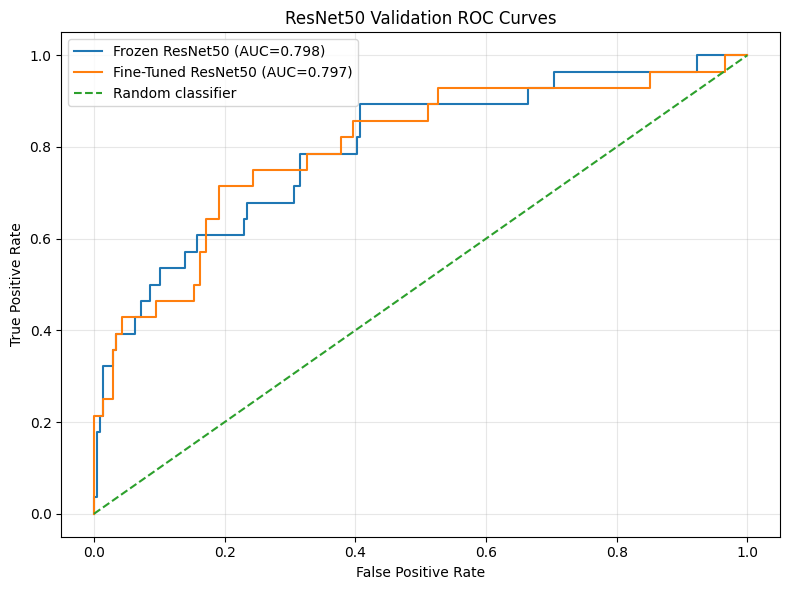

In [ ]:
# ============================================================
# Validation ROC Curves
# ============================================================

baseline_fpr, baseline_tpr, _ = roc_curve(
    validation_true,
    resnet_baseline_validation_prob
)

fine_fpr, fine_tpr, _ = roc_curve(
    validation_true,
    resnet_fine_tuned_validation_prob
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=(
        "Frozen ResNet50 "
        f"(AUC={resnet_baseline_val_roc_auc:.3f})"
    )
)

plt.plot(
    fine_fpr,
    fine_tpr,
    label=(
        "Fine-Tuned ResNet50 "
        f"(AUC={resnet_fine_tuned_val_roc_auc:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ResNet50 Validation ROC Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

##45. Plot validation precision-recall curves

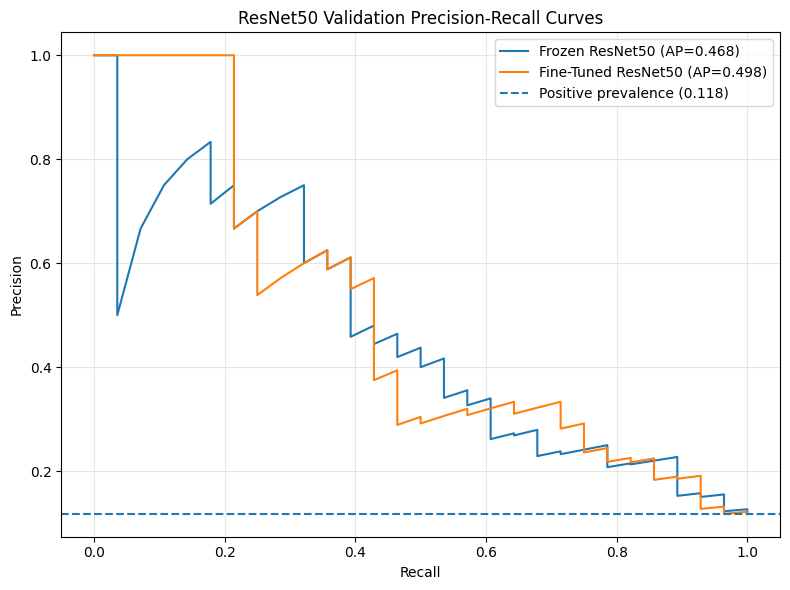

In [ ]:
# ============================================================
# Validation Precision-Recall Curves
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    baseline_recall_values,
    baseline_precision_values,
    label=(
        "Frozen ResNet50 "
        f"(AP={resnet_baseline_val_pr_auc:.3f})"
    )
)

plt.plot(
    fine_recall_values,
    fine_precision_values,
    label=(
        "Fine-Tuned ResNet50 "
        f"(AP={resnet_fine_tuned_val_pr_auc:.3f})"
    )
)

positive_prevalence = (
    validation_true.mean()
)

plt.axhline(
    positive_prevalence,
    linestyle="--",
    label=(
        "Positive prevalence "
        f"({positive_prevalence:.3f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "ResNet50 Validation Precision-Recall Curves"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

##46. Plot confusion matrix

In [ ]:
# ============================================================
# Confusion Matrix Plotting Function
# ============================================================

def plot_confusion_matrix(
    matrix,
    title
):

    plt.figure(
        figsize=(6, 5)
    )

    plt.imshow(
        matrix
    )

    plt.title(
        title
    )

    plt.colorbar()

    class_names = [
        "Benign",
        "Malignant"
    ]

    tick_positions = np.arange(
        len(class_names)
    )

    plt.xticks(
        tick_positions,
        class_names
    )

    plt.yticks(
        tick_positions,
        class_names
    )

    threshold = (
        matrix.max() / 2
    )

    for row_index in range(
        matrix.shape[0]
    ):

        for column_index in range(
            matrix.shape[1]
        ):

            plt.text(
                column_index,
                row_index,
                str(
                    matrix[
                        row_index,
                        column_index
                    ]
                ),
                horizontalalignment="center",
                verticalalignment="center"
            )

    plt.xlabel(
        "Predicted Label"
    )

    plt.ylabel(
        "True Label"
    )

    plt.tight_layout()

    plt.show()

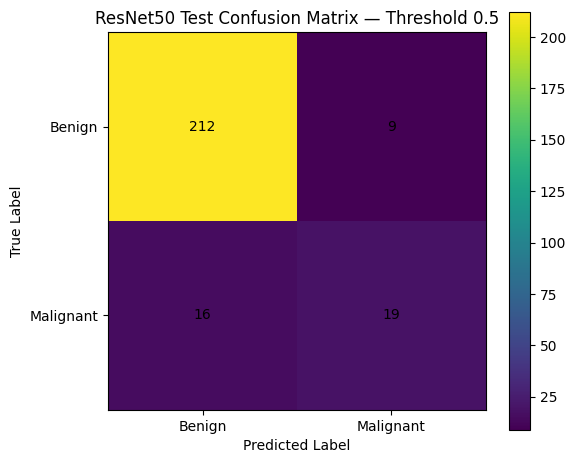

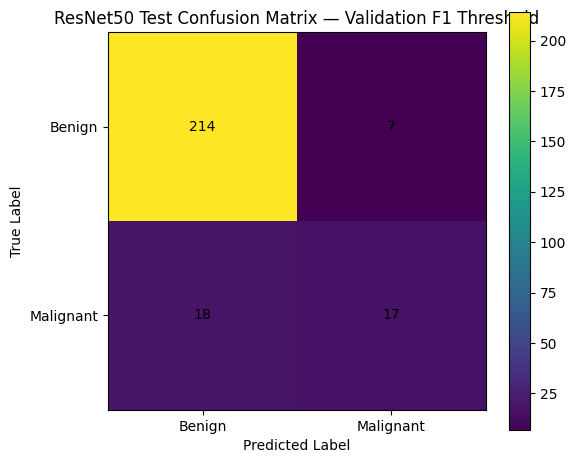

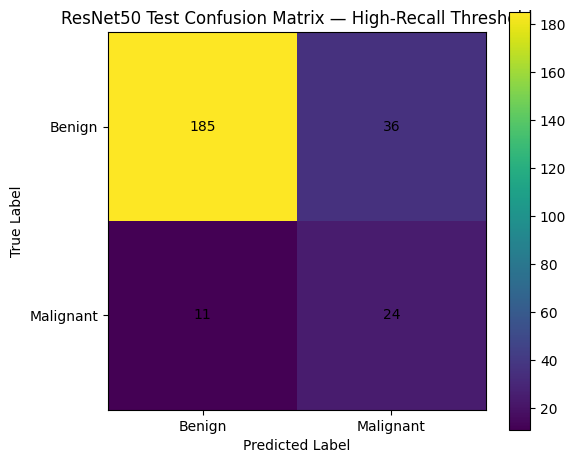

In [ ]:
plot_confusion_matrix(
    resnet_test_cm_default,
    "ResNet50 Test Confusion Matrix — Threshold 0.5"
)

plot_confusion_matrix(
    resnet_test_cm_balanced,
    "ResNet50 Test Confusion Matrix — Validation F1 Threshold"
)

plot_confusion_matrix(
    resnet_test_cm_high_recall,
    "ResNet50 Test Confusion Matrix — High-Recall Threshold"
)

##47. Save experiment results

In [ ]:
# ============================================================
# Save ResNet50 Experiment Summary
# ============================================================

resnet_experiment_summary = pd.DataFrame(
    [
        {
            "Selected Model":
                selected_resnet_name,

            "Baseline Validation ROC-AUC":
                resnet_baseline_val_roc_auc,

            "Baseline Validation PR-AUC":
                resnet_baseline_val_pr_auc,

            "Baseline Validation F1":
                resnet_baseline_best_val_f1,

            "Fine-Tuned Validation ROC-AUC":
                resnet_fine_tuned_val_roc_auc,

            "Fine-Tuned Validation PR-AUC":
                resnet_fine_tuned_val_pr_auc,

            "Fine-Tuned Validation F1":
                resnet_fine_tuned_best_val_f1,

            "Selected Validation F1 Threshold":
                selected_resnet_f1_threshold,

            "Selected High-Recall Threshold":
                selected_resnet_high_recall_threshold,

            "Test ROC-AUC":
                resnet_test_roc_auc,

            "Test PR-AUC":
                resnet_test_pr_auc
        }
    ]
)

RESNET_SUMMARY_PATH = (
    RESULTS_DIR
    / "resnet50_experiment_summary.csv"
)

RESNET_THRESHOLD_RESULTS_PATH = (
    RESULTS_DIR
    / "resnet50_test_threshold_results.csv"
)

RESNET_VALIDATION_COMPARISON_PATH = (
    RESULTS_DIR
    / "resnet50_validation_comparison.csv"
)

resnet_experiment_summary.to_csv(
    RESNET_SUMMARY_PATH,
    index=False
)

resnet_test_threshold_comparison.to_csv(
    RESNET_THRESHOLD_RESULTS_PATH,
    index=False
)

resnet_validation_comparison.to_csv(
    RESNET_VALIDATION_COMPARISON_PATH,
    index=False
)

print(
    "Saved experiment summary:",
    RESNET_SUMMARY_PATH
)

print(
    "Saved threshold results:",
    RESNET_THRESHOLD_RESULTS_PATH
)

print(
    "Saved validation comparison:",
    RESNET_VALIDATION_COMPARISON_PATH
)

display(
    resnet_experiment_summary
)

Saved experiment summary: /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/Results/resnet50_experiment_summary.csv
Saved threshold results: /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/Results/resnet50_test_threshold_results.csv
Saved validation comparison: /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/Results/resnet50_validation_comparison.csv


,Selected Model,Baseline Validation ROC-AUC,Baseline Validation PR-AUC,Baseline Validation F1,Fine-Tuned Validation ROC-AUC,Fine-Tuned Validation PR-AUC,Fine-Tuned Validation F1,Selected Validation F1 Threshold,Selected High-Recall Threshold,Test ROC-AUC,Test PR-AUC
0,Fine-Tuned ResNet50,0.797847,0.467531,0.478261,0.797163,0.497598,0.489796,0.600719,0.113742,0.822883,0.562283


##48. Save predictions

In [ ]:
# ============================================================
# Save Validation Predictions
# ============================================================

resnet_validation_predictions = pd.DataFrame(
    {
        "TrueLabel":
            validation_true,

        "BaselineProbability":
            resnet_baseline_validation_prob,

        "FineTunedProbability":
            resnet_fine_tuned_validation_prob
    }
)

RESNET_VALIDATION_PREDICTIONS_PATH = (
    RESULTS_DIR
    / "resnet50_validation_predictions.csv"
)

resnet_validation_predictions.to_csv(
    RESNET_VALIDATION_PREDICTIONS_PATH,
    index=False
)

In [ ]:
# ============================================================
# Save Test Predictions
# ============================================================

resnet_test_predictions = pd.DataFrame(
    {
        "TrueLabel":
            test_true,

        "PredictedProbability":
            resnet_test_probabilities,

        "PredictionDefault":
            resnet_test_pred_default,

        "PredictionF1Threshold":
            resnet_test_pred_balanced,

        "PredictionHighRecall":
            resnet_test_pred_high_recall
    }
)

RESNET_TEST_PREDICTIONS_PATH = (
    RESULTS_DIR
    / "resnet50_test_predictions.csv"
)

resnet_test_predictions.to_csv(
    RESNET_TEST_PREDICTIONS_PATH,
    index=False
)

print(
    "Saved validation predictions:",
    RESNET_VALIDATION_PREDICTIONS_PATH
)

print(
    "Saved test predictions:",
    RESNET_TEST_PREDICTIONS_PATH
)

Saved validation predictions: /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/Results/resnet50_validation_predictions.csv
Saved test predictions: /content/drive/MyDrive/Dissertation/Models/ResNet50/Corrected_Run_01/Results/resnet50_test_predictions.csv
